# Financial Data Analysis & Visualization

This notebook processes accounting data (imported from Excel/CSV), computes financial metrics, and visualizes trends.

**Key Phases:**
1.  **Data Loading**: Scans `../data/etica` for `.xls` files, converts them, and merges them.
2.  **Processing**: Computes the cumulative balance (`Saldo`), performs OLS linear regression, and resamples data into candlesticks.
3.  **Analysis**: Filters specific investment transactions and calculates derivatives.
4.  **Visualization**: Generates static plots (Matplotlib) for balances/derivatives and interactive plots (Plotly) for candlesticks.

In [1]:
from piggy_bank.src.etica import *

# Ensure plots display in the notebook
%matplotlib inline

logging.basicConfig(level=logging.DEBUG)

print('Loading data from', DATA_DIR)

Loading data from /home/pbertoni/opt/piggy-bank/data/etica


## 1. Data Loading & Preprocessing

This section handles the ingestion of raw financial data.

* **`load_xls_dataframes_from_import`**: Iterates through `.xls` files, cleans unnecessary columns (`Valuta`, `Causale`), converts them to CSV, and loads existing CSVs.
* **`merge_dataframes_no_duplicates`**: Combines multiple dataframes into a single dataset, ensuring no duplicate rows exist.
* **`sort_by_data_contabile`**: Sorts the merged dataframe chronologically by the accounting date (`Data contabile`).

In [2]:
_df_all = load_data()

print(f"Total rows in processed data: {_df_all.shape[0]}")
print(_df_all.head())

# Filter dataframes using the newly added 'Blacklisted' column
_df_net = _df_all[_df_all['Blacklisted'] == 0].copy().drop(columns=['Blacklisted'])
_df_blk = _df_all[_df_all['Blacklisted'] == 1].copy().drop(columns=['Blacklisted'])

print(f'Net entries: {_df_net.shape[0]}')
print(f'Blacklisted entries: {_df_blk.shape[0]}')

INFO:etica:Starting data load pipeline from /home/pbertoni/opt/piggy-bank/data/etica
INFO:etica:Loaded estrattocontoitalia-2026.csv into DataFrame with 426 rows.
INFO:etica:Loaded estrattocontoitalia-2022.csv into DataFrame with 15 rows.
INFO:etica:Loaded estrattocontoitalia-2024.csv into DataFrame with 47 rows.
INFO:etica:Loaded estrattocontoitalia-2025.csv into DataFrame with 173 rows.
INFO:etica:Loaded estrattocontoitalia-2023.csv into DataFrame with 35 rows.
INFO:etica:Dumped merged data (690 rows) to merged.csv
INFO:etica:Blacklisted entry matched: 2025-08-21
INFO:etica:Blacklisted entry matched: 2026-01-14
INFO:etica:Blacklisted entry matched: 2026-02-16
INFO:etica:Blacklisted entry matched: 2026-03-16
INFO:etica:Blacklisted entry matched: 2026-04-14
INFO:etica:Blacklisted entry matched: 2026-05-21
INFO:etica:Blacklisted entry matched: 2026-06-01


Total rows in processed data: 690
  Data contabile  Dare   Avere  Blacklisted
0     2022-03-25   NaN  1001.0            0
1     2022-03-29 -1.00     NaN            0
2     2022-03-29 -0.25     NaN            0
3     2022-03-29   NaN    50.0            0
4     2022-06-07   NaN    50.0            0
Net entries: 683
Blacklisted entries: 7


---
## 2. Financial Metrics & Computation

This section computes the core financial metrics:

* **`compute_importo`**: Creates the `Saldo` (cumulative balance) by summing Credits (`Avere`) and Debits (`Dare`).
* **`compute_ols`**: Performs an Ordinary Least Squares (OLS) linear regression on the balance over time to identify the trend (slope `m` and intercept `q`).
* **`compute_candlesticks`**: Resamples the raw transaction data into OHLC (Open, High, Low, Close) candlesticks for specific timeframes (Monthly/Weekly).

### Compute Balance and Regression

In [3]:
_df_net = compute_importo(_df_net)
_df_net, _m_net, _q_net = compute_ols(_df_net)
print(_df_net)

    Data contabile   Dare   Avere     Saldo           OLS
0       2022-03-25    NaN  1001.0   1001.00 -24648.121161
1       2022-03-29  -1.00     NaN   1000.00 -24447.221777
2       2022-03-29  -0.25     NaN    999.75 -24447.221777
3       2022-03-29    NaN    50.0   1049.75 -24447.221777
4       2022-06-07    NaN    50.0   1099.75 -20931.482556
..             ...    ...     ...       ...           ...
685     2026-07-27 -39.90     NaN  58195.70  54958.259766
686     2026-07-27  -0.25     NaN  58195.45  54958.259766
687     2026-07-28 -49.90     NaN  58145.55  55008.484612
688     2026-07-28 -44.84     NaN  58100.71  55008.484612
689     2026-07-28 -21.75     NaN  58078.96  55008.484612

[683 rows x 5 columns]


In [4]:
_df_all = compute_importo(_df_all)
_df_all, _m_mov, _q_mov = compute_ols(_df_all)
print(_df_all)

    Data contabile   Dare   Avere  Blacklisted     Saldo           OLS
0       2022-03-25    NaN  1001.0            0   1001.00   8842.299154
1       2022-03-29  -1.00     NaN            0   1000.00   8864.044254
2       2022-03-29  -0.25     NaN            0    999.75   8864.044254
3       2022-03-29    NaN    50.0            0   1049.75   8864.044254
4       2022-06-07    NaN    50.0            0   1099.75   9244.583508
..             ...    ...     ...          ...       ...           ...
685     2026-07-27 -39.90     NaN            0  10755.74  17458.795109
686     2026-07-27  -0.25     NaN            0  10755.49  17458.795109
687     2026-07-28 -49.90     NaN            0  10705.59  17464.231385
688     2026-07-28 -44.84     NaN            0  10660.75  17464.231385
689     2026-07-28 -21.75     NaN            0  10639.00  17464.231385

[690 rows x 6 columns]


In [5]:
_df_blk = compute_importo(_df_blk)
_df_blk, _m_blk, _q_blk = compute_ols(_df_blk)

## Main Plot: Saldo and OLS

DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/pbertoni/opt/piggy-bank/.venv/lib64/python3.14/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUni.ttf', name='STIXNonUnicode', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/pbertoni/opt/piggy-bank/.venv/lib64/python3.14/site-packages/matplotlib/mpl-data/fonts/ttf/cmmi10.ttf', name='cmmi10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/pbertoni/opt/piggy-bank/.venv/lib64/python3.14/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymBol.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:

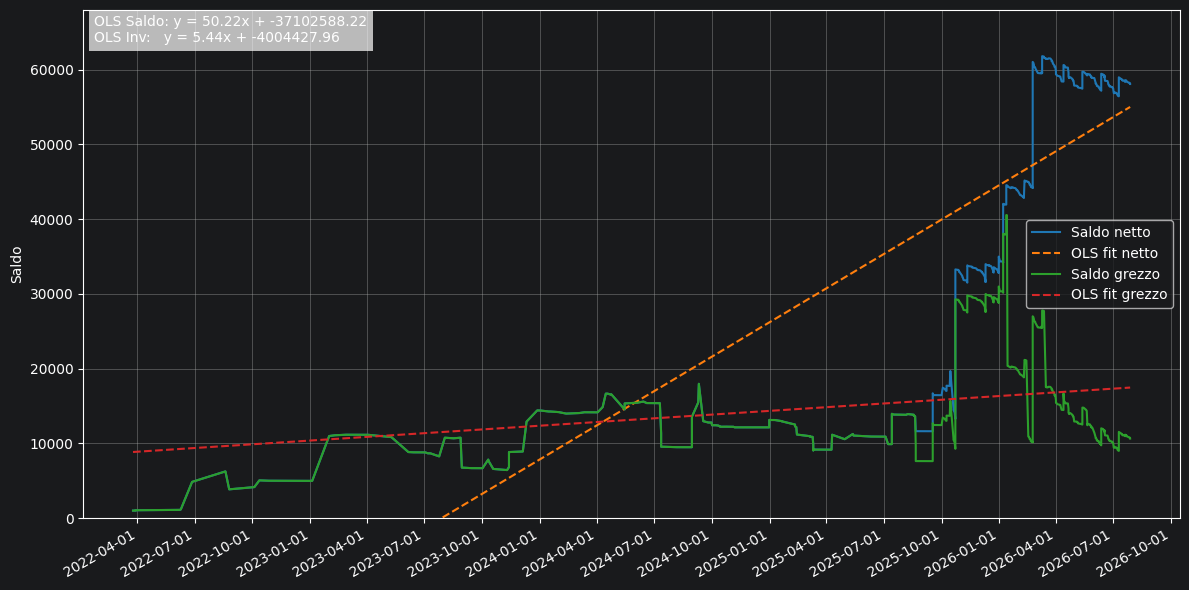

In [6]:
plot_saldo_ols(_df_net, _df_all)

In [7]:
plot_saldo_ols_interactive(_df_net, _df_all)

---
# Candlesticks

### Monthly

Also the derivative of the monthly closing balance (Change in `Close`).

In [ ]:
# Compute. Use ME for Month End, W for Weekly
_cndl_type = 'ME'
_cndl_lbl = 'Monthly' if _cndl_type == 'ME' else 'Weekly' if _cndl_type == 'W' else _cndl_type
_df_net_candles = compute_candlesticks(_df_net, _cndl_type)
_df_all_candles = compute_candlesticks(_df_all, _cndl_type)
print(f'{_cndl_lbl} candlesticks DataFrame head:\n{_df_net_candles.head()}')

In [ ]:
plot_candlestick(_df_net_candles, _cndl_lbl)

In [ ]:
plot_candlestick_interactive(_df_net_candles, 'Net')

In [ ]:
plot_candlestick_interactive(_df_all_candles, 'All')

---
## 3. Investment Filtering & Analysis

This section focuses on isolating investment-related transactions.

* **`filter_investments`**: Filters rows containing keywords like 'ETICA', 'FONDI', or 'DEPOSIT'.
* **Synthetic Bias**: Appends synthetic rows (`BILANCIO INIZIALE`) to simulate an initial balance or adjustment (bias) for accurate cumulative tracking.

In [ ]:
_df_inv = filter_investments(_df_net)
print_investments_summary(_df_inv)

Now plot the investment balance over time, if any investment transactions were found.

This will show how the investment-related balance evolved, which can be useful for tracking performance or identifying trends in the investment activities.

In [ ]:
plot_investments(_df_inv)